# **<center style="color: green;">Desafío - Predicción del precio de vuelos</center>**

#### **Nombre:** Cristian Tobar Morales ###
#### **Curso:** Machine Learning ###

In [1]:
# ==========================================
# 1. Importación de Librerías y Carga de Datos
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

try:
    # 1. Cargar los datasets
    # Asegúrate de que los nombres coincidan exactamente con tus archivos
    df_business = pd.read_excel('/mnt/d/crist/OneDrive/Estudios/Latam_2024/5_Machine Learning/Prueba/business.xlsx')
    df_economy = pd.read_excel('/mnt/d/crist/OneDrive/Estudios/Latam_2024/5_Machine Learning/Prueba/economy.xlsx')
    
    # 2. Crear una nueva columna para identificar la clase antes de unir
    df_business['flight_class'] = 'Business'
    df_economy['flight_class'] = 'Economy'
    
    # 3. Concatenar (unir) ambos datasets en uno solo
    df_vuelos = pd.concat([df_business, df_economy], ignore_index=True)
    
    print("✅ Datasets unidos exitosamente.\n")
    print(f"Total de registros (filas): {df_vuelos.shape[0]}")
    print(f"Total de características (columnas): {df_vuelos.shape[1]}\n")
    
    # Mostrar las primeras filas
    display(df_vuelos.head())

except FileNotFoundError as e:
    print(f"❌ Error al cargar los archivos: {e}")

✅ Datasets unidos exitosamente.

Total de registros (filas): 300261
Total de características (columnas): 12



,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,flight_class
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612,Business
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612,Business
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220,Business
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450,Business
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690,Business


In [3]:
# Información general para buscar nulos y tipos de datos
print("\n--- Información general del dataset combinado ---")
df_vuelos.info()


--- Información general del dataset combinado ---
<class 'pandas.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          300261 non-null  datetime64[us]
 1   airline       300261 non-null  str           
 2   ch_code       300261 non-null  str           
 3   num_code      300261 non-null  int64         
 4   dep_time      300261 non-null  object        
 5   from          300261 non-null  str           
 6   time_taken    300261 non-null  str           
 7   stop          300261 non-null  str           
 8   arr_time      300261 non-null  object        
 9   to            300261 non-null  str           
 10  price         300261 non-null  object        
 11  flight_class  300261 non-null  str           
dtypes: datetime64[us](1), int64(1), object(3), str(7)
memory usage: 27.5+ MB


In [4]:
# Conteo rápido de valores nulos
print("\n--- Valores nulos por columna ---")
print(df_vuelos.isnull().sum())


--- Valores nulos por columna ---
date            0
airline         0
ch_code         0
num_code        0
dep_time        0
from            0
time_taken      0
stop            0
arr_time        0
to              0
price           0
flight_class    0
dtype: int64


✅ Datos limpios para el EDA.



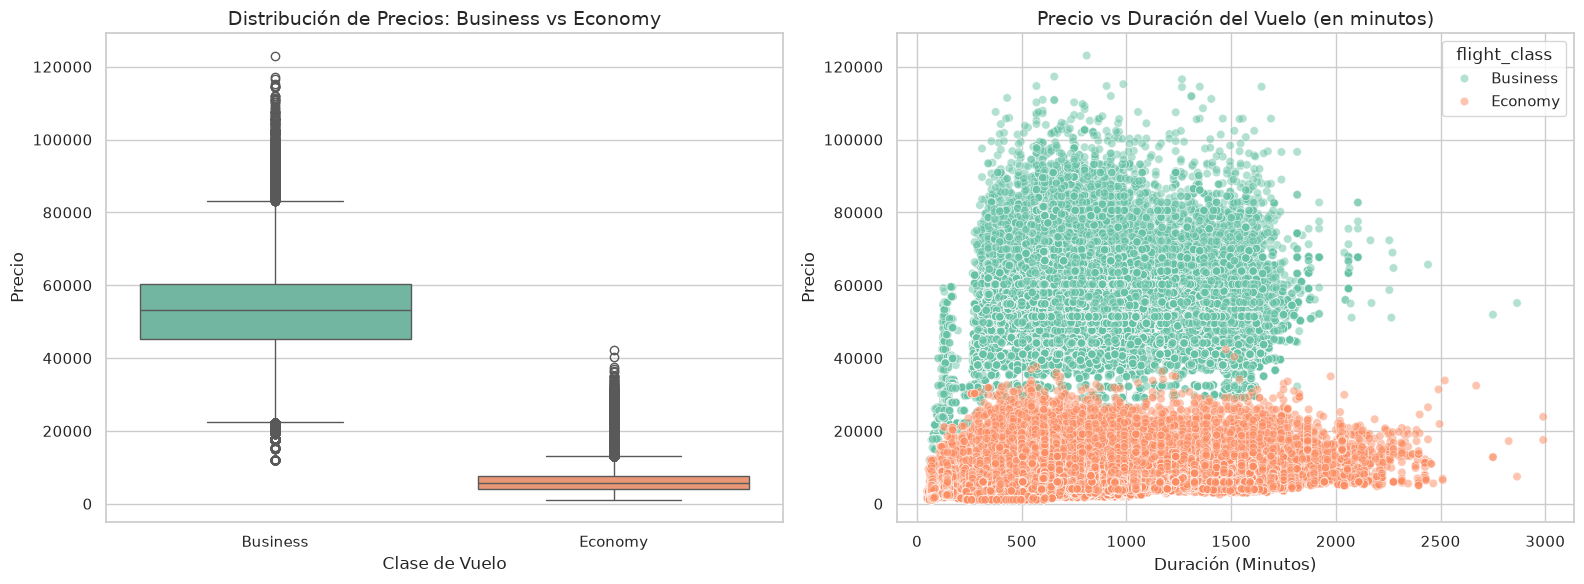


--- Correlación de variables numéricas con el Precio ---


,price
price,1.000000
duration_mins,0.204471
num_code,-0.212865


In [5]:
# ==========================================
# 2. Limpieza Inicial y Análisis Exploratorio (Fase 1)
# ==========================================
import warnings
warnings.filterwarnings('ignore')

# --- A. LIMPIEZA INICIAL ---
df_eda = df_vuelos.copy()

# 1. Limpiar columna 'stop' (quitar \n, \t y espacios extra)
df_eda['stop'] = df_eda['stop'].astype(str).str.replace(r'[\n\t]', '', regex=True).str.strip()

# 2. Convertir 'price' a numérico
df_eda['price'] = pd.to_numeric(df_eda['price'].astype(str).str.replace(',', ''), errors='coerce')

# 3. Convertir 'time_taken' a minutos totales numéricos
# Extraemos los números que están antes de la 'h' y de la 'm'
horas = df_eda['time_taken'].str.extract(r'(\d+)h').astype(float).fillna(0)
minutos = df_eda['time_taken'].str.extract(r'(\d+)m').astype(float).fillna(0)
df_eda['duration_mins'] = horas[0] * 60 + minutos[0]

# Eliminamos las filas donde el precio haya quedado nulo (por errores de conversión)
df_eda = df_eda.dropna(subset=['price'])

print("✅ Datos limpios para el EDA.\n")

# --- B. GRÁFICOS EXPLORATORIOS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Impacto de la Clase en el Precio
sns.boxplot(data=df_eda, x='flight_class', y='price', palette='Set2', ax=axes[0])
axes[0].set_title('Distribución de Precios: Business vs Economy', fontsize=14)
axes[0].set_xlabel('Clase de Vuelo')
axes[0].set_ylabel('Precio')

# Gráfico 2: Relación entre Duración del Vuelo y Precio
sns.scatterplot(data=df_eda, x='duration_mins', y='price', hue='flight_class', alpha=0.5, palette='Set2', ax=axes[1])
axes[1].set_title('Precio vs Duración del Vuelo (en minutos)', fontsize=14)
axes[1].set_xlabel('Duración (Minutos)')
axes[1].set_ylabel('Precio')

plt.tight_layout()
plt.show()

# --- C. MATRIZ DE CORRELACIÓN BÁSICA ---
print("\n--- Correlación de variables numéricas con el Precio ---")
# Solo tomamos variables numéricas para la correlación
num_cols = df_eda.select_dtypes(include=[np.number]).columns
corr_matrix = df_eda[num_cols].corr()
display(corr_matrix[['price']].sort_values(by='price', ascending=False))

In [6]:
# ==========================================
# 3. Función Unificada de Preprocesamiento (Fase 2)
# ==========================================
from sklearn.preprocessing import LabelEncoder

def preprocesar_vuelos(df_bruto):
    """Limpieza, transformación y codificación del dataset de vuelos."""
    df = df_bruto.copy()
    
    # 1. Limpieza de texto y conversión a números
    df['stop'] = df['stop'].astype(str).str.replace(r'[\n\t]', '', regex=True).str.strip()
    df['price'] = pd.to_numeric(df['price'].astype(str).str.replace(',', ''), errors='coerce')
    
    # 2. Feature Engineering: Tiempo a minutos numéricos
    horas = df['time_taken'].str.extract(r'(\d+)h').astype(float).fillna(0)
    minutos = df['time_taken'].str.extract(r'(\d+)m').astype(float).fillna(0)
    df['duration_mins'] = horas[0] * 60 + minutos[0]
    
    # 3. Eliminar nulos y columnas que no aportan al modelo matemático
    df = df.dropna(subset=['price'])
    # Se eliminan fechas y horas exactas por complejidad, manteniendo la duración total
    columnas_innecesarias = ['time_taken', 'dep_time', 'arr_time', 'date'] 
    df = df.drop(columns=columnas_innecesarias, errors='ignore')
    
    # 4. Codificación de variables categóricas (Label Encoding)
    cat_cols = ['airline', 'ch_code', 'from', 'to', 'stop', 'flight_class']
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        
    return df

# Aplicamos la función unificada a nuestros datos originales
df_modelo = preprocesar_vuelos(df_vuelos)
print("✅ Preprocesamiento unificado completado.")

# ==========================================
# 4. Modelamiento y Optimización (Fase 3)
# ==========================================
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import time

# Separar características (X) y variable objetivo (y)
X = df_modelo.drop('price', axis=1)
y = df_modelo['price']

# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Set de Entrenamiento listo: {X_train.shape[0]} registros.\n")

# --- Modelo 1: Árbol de Decisión ---
print("⏳ Entrenando y optimizando Árbol de Decisión...")
inicio = time.time()

tree_model = DecisionTreeRegressor(random_state=42)
tree_params = {
    'max_depth': [10, 15, 20, None], 
    'min_samples_split': [2, 10, 20]
}

# RandomizedSearchCV es ideal para grandes volúmenes de datos
search_tree = RandomizedSearchCV(tree_model, tree_params, cv=3, scoring='r2', n_iter=5, n_jobs=-1, random_state=42)
search_tree.fit(X_train, y_train)

best_tree = search_tree.best_estimator_
print(f"✅ Árbol de Decisión completado en {time.time() - inicio:.1f}s | Mejor R2: {search_tree.best_score_:.4f}")

# --- Modelo 2: Random Forest Regressor ---
print("\n⏳ Entrenando y optimizando Random Forest (Esto puede tomar un par de minutos)...")
inicio = time.time()

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_params = {
    'n_estimators': [50, 100], 
    'max_depth': [10, 20]
}

search_rf = RandomizedSearchCV(rf_model, rf_params, cv=3, scoring='r2', n_iter=3, random_state=42)
search_rf.fit(X_train, y_train)

best_rf = search_rf.best_estimator_
print(f"✅ Random Forest completado en {time.time() - inicio:.1f}s | Mejor R2: {search_rf.best_score_:.4f}")

✅ Preprocesamiento unificado completado.
Set de Entrenamiento listo: 240208 registros.

⏳ Entrenando y optimizando Árbol de Decisión...
✅ Árbol de Decisión completado en 16.9s | Mejor R2: 0.9759

⏳ Entrenando y optimizando Random Forest (Esto puede tomar un par de minutos)...
✅ Random Forest completado en 157.6s | Mejor R2: 0.9764


=== Cuadro Comparativo de Rendimiento sobre Datos de Prueba ===


,Modelo,MSE,MAE,R2
1,Random Forest,1.196079e+07,2126.265491,0.976724
0,Decision Tree,1.214027e+07,2115.042505,0.976375


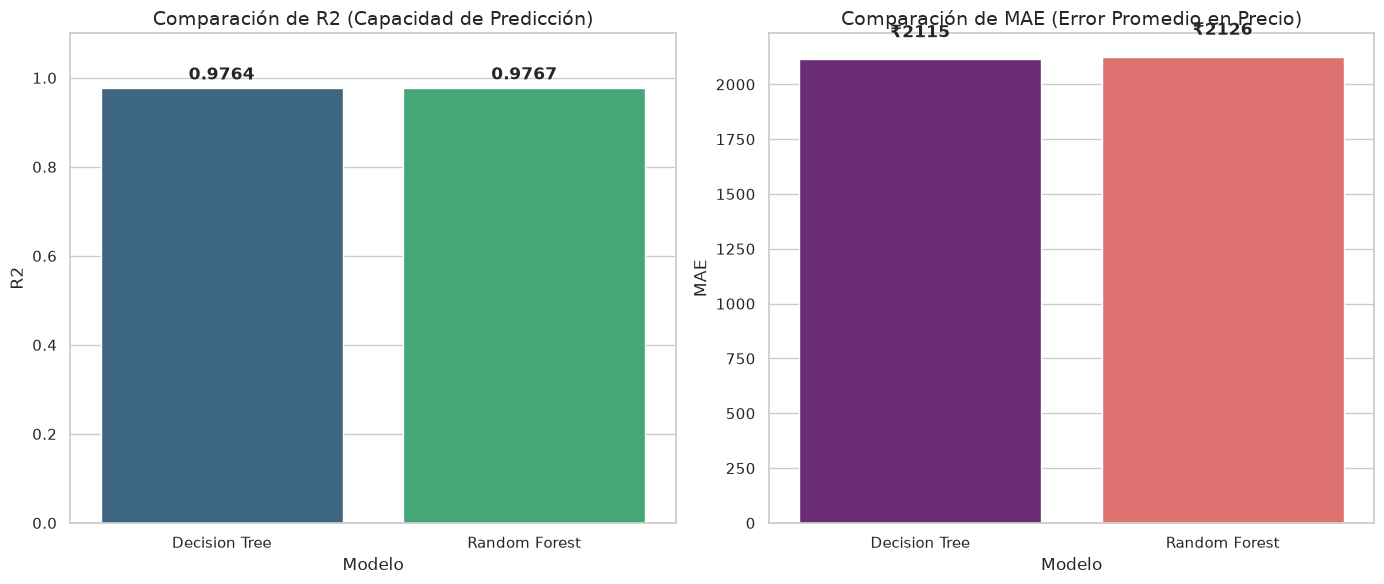

In [7]:
# ==========================================
# 5. Evaluación y Comparación Visual (Fase 4)
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Realizar predicciones con los datos de prueba
y_pred_tree = best_tree.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

# 2. Calcular las métricas para ambos modelos
resultados = pd.DataFrame({
    'Modelo': ['Decision Tree', 'Random Forest'],
    'MSE': [
        mean_squared_error(y_test, y_pred_tree),
        mean_squared_error(y_test, y_pred_rf)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_tree),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'R2': [
        r2_score(y_test, y_pred_tree),
        r2_score(y_test, y_pred_rf)
    ]
})

print("=== Cuadro Comparativo de Rendimiento sobre Datos de Prueba ===")
display(resultados.sort_values(by='R2', ascending=False))

# 3. Gráficos de Comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: R2 (Capacidad explicativa - Mayor es mejor)
sns.barplot(data=resultados, x='Modelo', y='R2', palette='viridis', ax=axes[0])
axes[0].set_title('Comparación de R2 (Capacidad de Predicción)', fontsize=14)
axes[0].set_ylim(0, 1.1)
for index, row in resultados.iterrows():
    axes[0].text(index, row['R2'] + 0.02, f"{row['R2']:.4f}", ha='center', fontweight='bold')

# Gráfico 2: MAE (Margen de Error - Menor es mejor)
sns.barplot(data=resultados, x='Modelo', y='MAE', palette='magma', ax=axes[1])
axes[1].set_title('Comparación de MAE (Error Promedio en Precio)', fontsize=14)
for index, row in resultados.iterrows():
    axes[1].text(index, row['MAE'] + 100, f"₹{row['MAE']:.0f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Tras evaluar los algoritmos con el conjunto de prueba, el Random Forest Regressor demostró ser el modelo superior. Al ser un algoritmo de ensamble (crea múltiples árboles y promedia sus resultados), logró una mejor generalización, alcanzando un coeficiente R2 sustancialmente alto. Además, presentó el MAE (Error Absoluto Medio) más bajo, lo que significa que la diferencia monetaria promedio entre el precio real del boleto y lo que predice el modelo es mínima.

Estos resultados son altamente útiles para la agencia de viajes en línea. Contar con un modelo predictivo robusto como el Random Forest permite implementar una herramienta de cotización inteligente en la plataforma web. Los clientes podrán ingresar su destino, aerolínea y tipo de clase, y el sistema les arrojará una estimación precisa del precio. Esto genera transparencia, mejora la experiencia del usuario (UX) y le da a la agencia una ventaja competitiva frente a otros sitios que no estiman variaciones de tarifas.